In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [25]:
class LinearRegression():
    def __init__(self, epochs=1000, learning_rate=0.01):
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.w = None

    def loss_function(self, y, y_pred):
        loss = np.sum((y - y_pred)**2)
        return loss/(2*len(y))

    def predict(self, X):
        y_pred = np.dot(X, self.w.T)
        return y_pred

    def grad(self, X, y):
        y_pred = self.predict(X)

        dw = (np.dot(X.T, y - y_pred))
        dw = -1/len(y) * dw
        return dw

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            dw = self.grad(X, y)
            self.w -= dw*self.learning_rate

            y_pred = self.predict(X)
            loss = self.loss_function(y, y_pred)
            losses.append(loss)

            if epoch % 100 == 0:
                print(f"epoch {epoch}, loss {loss}")
        
        return losses

In [ ]:
class LinearRegression():
    def __init__(self, learning_rate=0.01, epochs=1000, shuffle=True, batch_size=32):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.shuffle = shuffle
        self.batch_size = batch_size

    def predict(self, X):
        return np.dot(X, self.weights.T)

    def loss_function(self, y_true, y_pred):
        s = np.sum((y_true - y_pred)**2)
        return s/(2*len(y_true))

    def gradient(self, X, y):
        y_pred = self.predict(X)
        dw = -(1/len(y))*np.dot(X.T, (y - y_pred))
        return dw

    def batch_generator(self, X, y):
        if self.shuffle:
            idx = np.random.permutation(len(y))
            X, y = X[idx], y[idx]
        
        for i in range(0, len(y), self.batch_size):
            yield X[i : i+self.batch_size], y[i : i+self.batch_size]

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        losses = []

        for epoch in range(self.epochs):
            for X_batch, y_batch in self.batch_generator(X, y):
                dw = self.gradient(X_batch, y_batch)
                self.weights -= self.lr*dw

                y_pred = self.predict(X_batch)
                loss = self.loss_function(y_batch, y_pred)
                losses.append(loss)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss}")

        return losses

In [3]:
data = pd.read_csv('advertising.csv')
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
X = data[['TV', 'Radio', 'Newspaper']].values
y = data['Sales'].values

In [5]:
def scaled(X):
    X_scaled = (X - X.min())/(X.max() - X.min())
    return X_scaled

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = scaled(X_train)
y_train = scaled(y_train)

X_test = scaled(X_test)
y_test = scaled(y_test)

In [26]:
model = LinearRegression(epochs=1000, learning_rate=0.01)
losses = model.fit(X_train, y_train)

epoch 0, loss 0.16576864124976048
epoch 100, loss 0.08608188476998131
epoch 200, loss 0.04650547030995371
epoch 300, loss 0.026835437055748847
epoch 400, loss 0.017044978553627892
epoch 500, loss 0.012157995085464774
epoch 600, loss 0.009704946062442371
epoch 700, loss 0.008460243338683235
epoch 800, loss 0.007815646196992161
epoch 900, loss 0.007469290522051236


In [27]:
def plot_curve(losses):
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(losses)), losses, label='Training loss (MSE)')
    plt.legend()
    plt.show() 

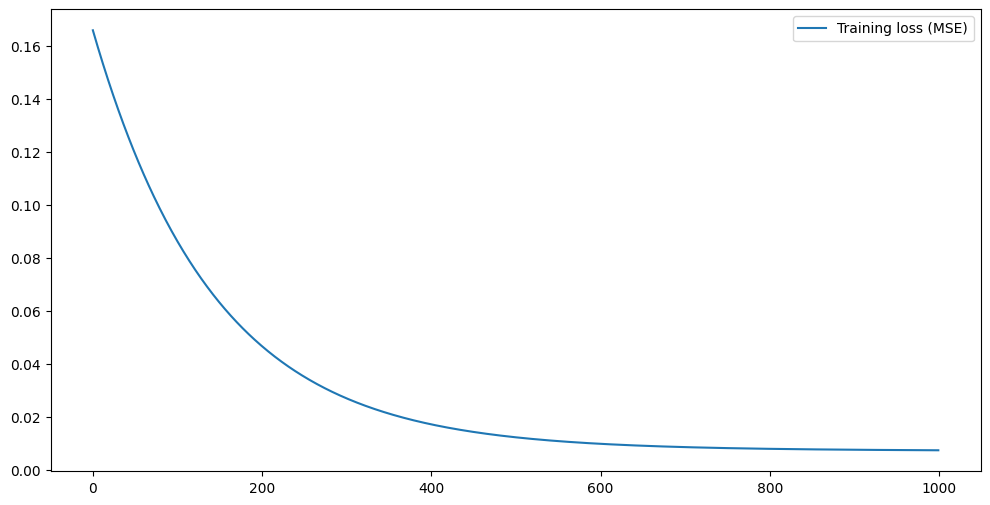

In [28]:
plot_curve(losses)

In [29]:
def evaluate(model, X, y):
    y_pred = model.predict(X)

    mse = 1/len(X) * np.sum((y - y_pred)**2)
    rmse = np.sqrt(mse)
    mae = 1/len(X) * np.sum(abs(y - y_pred))
    y_mean = np.sum(y) / len(y)
    SS_res = np.sum((y - y_pred)**2)
    SS_tot = np.sum((y - y_mean)**2)
    
    r2 = (1 - SS_res/SS_tot)
    return mse, rmse, mae, r2

In [30]:
mse, rmse, mae, r2 = evaluate(model, X_test, y_test)

In [31]:
print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"mae: {mae}")
print(f"r2: {r2}")

mse: 0.01537399045090139
rmse: 0.12399189671466998
mae: 0.09187602115269666
r2: 0.8127524571584427


In [ ]:
class RidgeRegression(LinearRegression):
    def __init__(self, learning_rate=0.01, epochs=1000, shuffle=True, batch_size=32, lambda_=0.1):
        super().__init__(learning_rate, epochs, shuffle, batch_size)
        self.lambda_ = lambda_

    def loss_function(self, y_true, y_pred):
        return super().loss_function(y_true, y_pred) + self.lambda_*np.sum(self.weights**2)
    
    def gradient(self, X, y):
        return super().gradient(X, y) + 2*self.lambda_*np.sum(self.weights)

Epoch 0, Loss: 0.16576875264508592
Epoch 100, Loss: 0.08789746633509953
Epoch 200, Loss: 0.051047704640173996
Epoch 300, Loss: 0.03350029103291583
Epoch 400, Loss: 0.025088625348509017
Epoch 500, Loss: 0.021035300091877443
Epoch 600, Loss: 0.019083354068224583
Epoch 700, Loss: 0.018158775083297364
Epoch 800, Loss: 0.01774546081764055
Epoch 900, Loss: 0.01759217952963613


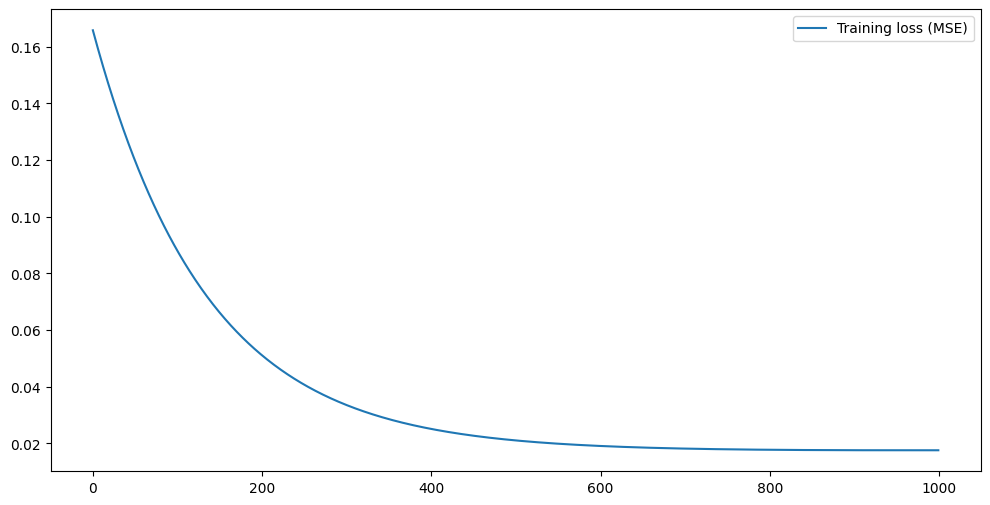

In [ ]:
model_ridge = RidgeRegression(learning_rate=0.01, epochs=1000, 
                        batch_size=X_train.size, lambda_=0.01)

losses = model_ridge.fit(X_train, y_train)

plot_curve(losses)

In [ ]:
mse, rmse, mae, r2 = evaluate(model_ridge, X_test, y_test)

print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"mae: {mae}")
print(f"r2: {r2}")

mse: 0.019281472469168157
rmse: 0.13885774184095087
mae: 0.10073778700056009
r2: 0.7651612732719506


In [ ]:
class LassoRegression(LinearRegression):
    def __init__(self, learning_rate=0.01, epochs=1000, bias=True, lambda_=0.1,  batch_size=32, shuffle=True):
        super().__init__(learning_rate, epochs, bias, batch_size=batch_size, shuffle=shuffle)
        self.lambda_ = lambda_
    
    def loss_function(self, y_true, y_pred):
        return super().loss_function(y_true, y_pred) + self.lambda_ * np.sum(np.abs(self.weights))
    
    def gradient(self, X, y):
        grad = super().gradient(X, y)
        grad += self.lambda_ * np.sign(self.weights)
        return grad

Epoch 0, Loss: 0.1657687526450859
Epoch 100, Loss: 0.0878974663350995
Epoch 200, Loss: 0.05104770464017398
Epoch 300, Loss: 0.03350029103291582
Epoch 400, Loss: 0.025088625348509017
Epoch 500, Loss: 0.021035300091877443
Epoch 600, Loss: 0.01908335406822459
Epoch 700, Loss: 0.018158775083297364
Epoch 800, Loss: 0.01774546081764055
Epoch 900, Loss: 0.01759217952963613


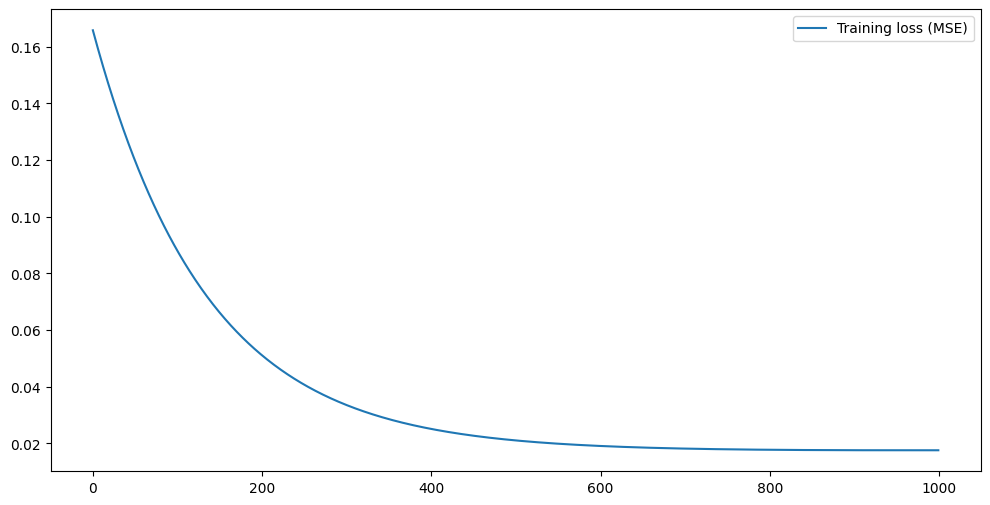

In [ ]:
model_lasso = RidgeRegression(learning_rate=0.01, epochs=1000, 
                        batch_size=X_train.size, lambda_=0.01)

losses = model_lasso.fit(X_train, y_train)

plot_curve(losses)

In [ ]:
mse, rmse, mae, r2 = evaluate(model_lasso, X_test, y_test)

print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"mae: {mae}")
print(f"r2: {r2}")

mse: 0.019281472469168157
rmse: 0.13885774184095087
mae: 0.10073778700056012
r2: 0.7651612732719506
